In [148]:
import os
import json
from typing import Annotated, List, Literal, TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")

In [2]:
from pydantic import BaseModel, Field
from typing import List, Literal

ThemeOptions = Literal[
    "executive_dark",
    "swiss_minimalist",
    "tech_brutalist",
    "nordic_serene",
    "cyber_punk",
    "editorial_vogue",
    "industrial_loft",
    "startup_bold",
    "classic_heritage",
    "the_ghost"
]

from typing import Literal

# All layout names categorized for the Pydantic field
LayoutOptions = Literal[
    # Title & Hero
    "title_hero_centered", "title_split_accent_left", "title_minimal_right_aligned", 
    "title_frame_centered_box", "title_asymmetric_impact_diagonal",
    
    # Content & Narrative
    "content_narrative_single_column", "content_bullets_with_sidebar_title", 
    "content_bullets_header_bar", "content_narrative_right_offset", 
    "content_bullets_centered_narrow", "content_text_over_ghost_title",
    
    # Section Breaks
    "section_highlight_giant_number", "section_minimal_centered", 
    "section_bottom_anchor_line", "section_dark_background_reveal", 
    "section_clean_geometric_center", "section_horizon_divider_clean", 
    "section_block_anchor_footer", "section_editorial_corner_accent",
    
    # Two-Column & Comparison
    "two_column_asymmetric_golden_ratio", "two_column_split_cards", 
    "two_column_mirrored_paragraphs", "two_column_list_with_callout", 
    "two_column_staggered_text", "two_column_centered_divider", 
    "two_column_clean_bullets", "compare_three_column_grid", 
    "compare_four_quadrant_grid", "compare_t_shape_columns", 
    "compare_split_high_contrast", "compare_two_floating_boxes",
    
    # Impact & Image
    "impact_quote_master", "impact_top_banner_minimal", "impact_centered_huge_text", 
    "image_full_with_bottom_caption", "image_sidebar_with_left_text", 
    "image_centered_inset_with_caption", "image_storyteller_text_left", 
    "image_technical_bullets_right", "image_full_bleed_background", 
    "image_gallery_framed_portrait", "image_panorama_with_dual_captions", 
    "image_text_overlap_depth", "image_split_dual_overlay", 
    "gallery_dual_image_feature", "gallery_triple_image_portfolio", 
    "editorial_sidebar_image_left"
]

class Slide(BaseModel):
    slide_id: int
    slide_premise: str = Field(
        description="A detailed description of what this slide will cover and its visual intent."
    )
    layout: LayoutOptions = Field(
        description="The layout that best supports the visual intent described in the premise."
    )

class PresentationPlan(BaseModel):
    theme: ThemeOptions = Field(description="The aesthetic theme that matches the overall topic.")
    slides: List[Slide]



#planner node

In [3]:
system_instruction = """
You are an expert Presentation Architect designing a fully automated,
content-driven PowerPoint presentation.

This presentation is generated WITHOUT human narration.
Every slide must be self-explanatory through content and layout choice.

Your MOST IMPORTANT task is CORRECT LAYOUT SELECTION.

====================================================
GLOBAL PRINCIPLES (NON-NEGOTIABLE)
====================================================

- This is NOT a quote deck.
- This is NOT a title-only slideshow.
- This IS a structured explanatory document in slide form.
- Every slide must justify its layout choice.

====================================================
LAYOUT FAMILIES AND WHEN TO USE THEM
====================================================

--------------------
TITLE LAYOUTS
--------------------
(title_hero_centered, title_split_accent_left,
 title_minimal_right_aligned, title_frame_centered_box,
 title_asymmetric_impact_diagonal)

• Use ONLY for:
  - Slide 1 (mandatory introduction)
  - Rare emphasis slides in the middle (optional)
• MUST include both title and subtitle when available
• MUST NOT be used for the conclusion

--------------------
CONTENT / NARRATIVE LAYOUTS
--------------------
(content_narrative_single_column,
 content_narrative_right_offset,
 content_text_over_ghost_title)

• Use to EXPLAIN concepts clearly
• Preferred for:
  - Definitions
  - Explanations
  - Background
  - Conclusions
• These layouts should form the backbone of the deck

--------------------
BULLET-BASED CONTENT LAYOUTS
--------------------
(content_bullets_with_sidebar_title,
 content_bullets_header_bar,
 content_bullets_centered_narrow)

• Use when listing:
  - Points
  - Steps
  - Features
  - Consequences
• Bullets must carry real information, not placeholders

--------------------
TWO-COLUMN / COMPARISON LAYOUTS
--------------------
(two_column_asymmetric_golden_ratio,
 two_column_split_cards,
 two_column_mirrored_paragraphs,
 two_column_list_with_callout,
 two_column_staggered_text,
 two_column_centered_divider,
 two_column_clean_bullets,
 compare_three_column_grid,
 compare_four_quadrant_grid,
 compare_t_shape_columns,
 compare_split_high_contrast,
 compare_two_floating_boxes)

• Use ONLY when there is a TRUE comparison or contrast
• Examples:
  - Pros vs Cons
  - Before vs After
  - Option A vs Option B
• Do NOT use comparison layouts without clear contrast

--------------------
IMAGE-BASED LAYOUTS
--------------------
(image_full_with_bottom_caption,
 image_sidebar_with_left_text,
 image_centered_inset_with_caption,
 image_storyteller_text_left,
 image_technical_bullets_right,
 image_full_bleed_background,
 image_gallery_framed_portrait,
 image_panorama_with_dual_captions,
 image_text_overlap_depth,
 image_split_dual_overlay,
 gallery_dual_image_feature,
 gallery_triple_image_portfolio,
 editorial_sidebar_image_left)

• Use ONLY when visuals help EXPLAIN the idea
• Images must support understanding, not decoration
• Always include supporting text or captions

--------------------
SECTION / DIVIDER LAYOUTS
--------------------
- Section divider layouts are ALLOWED ONLY if total number of slides > 12.
- If num_slides ≤ 12, DO NOT use ANY section or divider layouts.
- Do NOT make exceptions.
-Do NOT use  section layouts, unless they begin a new topic.

(section_highlight_giant_number,
 section_minimal_centered,
 section_bottom_anchor_line,
 section_dark_background_reveal,
 section_clean_geometric_center,
 section_horizon_divider_clean,
 section_block_anchor_footer,
 section_editorial_corner_accent)

• Use VERY SPARINGLY
• ONLY when:
  - A major topic shift occurs
  - A new phase of the presentation begins
• Do NOT overuse section slides
• Section slides must feel structurally necessary

--------------------
IMPACT LAYOUTS
--------------------
(impact_quote_master,
 impact_top_banner_minimal,
 impact_centered_huge_text)

• Use ONLY for emphasis in the middle of the deck
• MUST contain meaningful content
• MUST NOT be used as a content-less conclusion

====================================================
CONCLUSION SLIDE (CRITICAL RULE)
====================================================

• The final slide MUST:
  - Have a clear title
  - Have explanatory content
• It MUST summarize, reflect, or close the topic properly
• Title-only or quote-only conclusions are NOT allowed
• Prefer narrative or structured content layouts for conclusions

====================================================
LAYOUT DIVERSITY RULES
====================================================

- Do NOT repeat the same layout consecutively
- Do NOT default to the same layout for similar slides
- Choose layouts intentionally based on slide purpose

====================================================
SLIDE PREMISE REQUIREMENT
====================================================

For EVERY slide, write a slide_premise that:
- Explains what content appears
- Explains why this layout is chosen
- Proves the layout is appropriate

====================================================
QUALITY BAR
====================================================

The presentation should look like it was designed by
a professional human designer for automated consumption,
not like a generic template slideshow.
"""


In [4]:
from langchain_core.prompts import ChatPromptTemplate

def planner_node(llm):

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction),
        ("user", "Create a {num_slides} slide presentation about: {topic}.")
    ])

    return prompt | llm.with_structured_output(PresentationPlan)


planner = planner_node(llm)


In [5]:
response=planner.invoke({"num_slides":10,"topic":"history of black hole"})

In [6]:
print(f"Theme: {response.theme}\n")

for slide in response.slides:
    print(f"Slide {slide.slide_id}")
    print(f"Layout   : {slide.layout}")
    print(f"Premise  : {slide.slide_premise}")
    print("-" * 60)

Theme: tech_brutalist

Slide 1
Layout   : title_hero_centered
Premise  : Introduction to the history of black holes, with a title and subtitle to set the stage for the presentation. The title_hero_centered layout is chosen to grab the audience's attention and provide a clear introduction.
------------------------------------------------------------
Slide 2
Layout   : content_narrative_single_column
Premise  : Explanation of the early theories of black holes, including the work of John Michell and Pierre-Simon Laplace. The content_narrative_single_column layout is chosen to provide a clear and concise explanation of the historical context.
------------------------------------------------------------
Slide 3
Layout   : content_bullets_with_sidebar_title
Premise  : Discussion of the role of Albert Einstein's theory of general relativity in the development of modern black hole theory. The content_bullets_with_sidebar_title layout is chosen to highlight key points and provide additional con

slot fetcher node 

In [7]:
from pydantic import BaseModel
from typing import Dict, Any, List


In [8]:
from pydantic import BaseModel
from typing import List, Literal

SlotType = Literal["text", "paragraph", "bullets", "image"]

class SlotBlueprint(BaseModel):
    slot_key: str
    type: SlotType
    w: float
    h: float


class SlideWithSlots(BaseModel):
    slide_id: int
    premise: str
    slots: List[SlotBlueprint]


In [94]:
import json

def load_design_system(json_path: str) -> dict:
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)



In [95]:
design_system = load_design_system("finalfinalppt.json")


In [ ]:
def slot_fetcher_node(slides: List[Slide], design_system: dict) -> List[SlideWithSlots]:

    resolved_slides = []
    layouts = design_system["layouts"]

    for slide in slides:
        layout_name = slide.layout

        if layout_name not in layouts:
            raise ValueError(f"Layout '{layout_name}' not found")

        layout_slots = layouts[layout_name]["slots"]
        slot_blueprints = []

        for slot_key, slot_def in layout_slots.items():
            slot_type = slot_def.get("type")

            # ❌ Ignore shapes
            if slot_type == "shape":
                continue

            slot_blueprints.append(
                SlotBlueprint(
                    slot_key=slot_key,
                    type=slot_type,
                    w=float(slot_def["w"]),
                    h=float(slot_def["h"])
                )
            )

        resolved_slides.append(
            SlideWithSlots(
                slide_id=slide.slide_id,
                premise=slide.slide_premise,
                slots=slot_blueprints
            )
        )

    return resolved_slides


In [96]:
slot_output = slot_fetcher_node(
    slides=response.slides,
    design_system=design_system
)


In [97]:
for slide in slot_output:
    print(f"slide_id: {slide.slide_id}")
    print("slots:")
    for s in slide.slots:
        print(
            f"  SlotBlueprint("
            f"slot_key='{s.slot_key}', "
            f"w={s.w}, h={s.h}, "
            f"type='{s.type}'"
            f")"
        )
    print("-" * 40)


slide_id: 1
slots:
  SlotBlueprint(slot_key='title', w=8.0, h=1.2, type='text')
  SlotBlueprint(slot_key='subtitle', w=6.0, h=0.6, type='text')
----------------------------------------
slide_id: 2
slots:
  SlotBlueprint(slot_key='title', w=6.0, h=1.0, type='text')
  SlotBlueprint(slot_key='body', w=6.0, h=4.5, type='paragraph')
----------------------------------------
slide_id: 3
slots:
  SlotBlueprint(slot_key='title', w=2.5, h=4.0, type='text')
  SlotBlueprint(slot_key='bullets', w=6.0, h=5.0, type='bullets')
----------------------------------------
slide_id: 4
slots:
  SlotBlueprint(slot_key='visual', w=9.0, h=5.5, type='image')
  SlotBlueprint(slot_key='caption', w=9.0, h=0.7, type='text')
----------------------------------------
slide_id: 5
slots:
  SlotBlueprint(slot_key='main_title', w=9.0, h=0.8, type='text')
  SlotBlueprint(slot_key='title_1', w=2.8, h=0.6, type='text')
  SlotBlueprint(slot_key='body_1', w=2.8, h=4.0, type='text')
  SlotBlueprint(slot_key='title_2', w=2.8, h=0

orchastraotor node

In [15]:
from pydantic import BaseModel
from typing import List

class OrchestratedSlide(BaseModel):
    slide_id: int
    premise: str
    slots: List[SlotBlueprint]


In [ ]:
def orchestrator_node(planner_slides: List[Slide], slot_slides: List[SlideWithSlots]) -> List[OrchestratedSlide]:

    # Build lookup from slot fetcher output
    slot_map = {
        slide.slide_id: slide.slots
        for slide in slot_slides
    }

    orchestrated = []

    for slide in planner_slides:
        if slide.slide_id not in slot_map:
            raise ValueError(f"Missing slots for slide_id {slide.slide_id}")

        orchestrated.append(
            OrchestratedSlide(
                slide_id=slide.slide_id,
                premise=slide.slide_premise,
                slots=slot_map[slide.slide_id]
            )
        )

    return orchestrated


In [17]:

orchestrator_output = orchestrator_node(
    planner_slides=response.slides,
    slot_slides=slot_output
)

# ✅ DEFINE slides_with_slots
slides_with_slots = [
    {
        "slide_id": slide.slide_id,
        "premise": slide.premise,
        "slots": [
            {
                "slot_key": s.slot_key,
                "type": s.type,
                "w": s.w,
                "h": s.h
            }
            for s in slide.slots
        ]
    }
    for slide in orchestrator_output
]


In [18]:
print(slides_with_slots[0])


{'slide_id': 1, 'premise': "Introduction to the history of black holes, with a title and subtitle to set the stage for the presentation. The title_hero_centered layout is chosen to grab the audience's attention and provide a clear introduction.", 'slots': [{'slot_key': 'title', 'type': 'text', 'w': 8.0, 'h': 1.2}, {'slot_key': 'subtitle', 'type': 'text', 'w': 6.0, 'h': 0.6}]}


In [19]:
orchestrator_output = orchestrator_node(
    planner_slides=response.slides,
    slot_slides=slot_output
)


In [20]:
for slide in orchestrator_output:
    print(f"slide_id: {slide.slide_id}")
    print(f"premise: {slide.premise}")
    print("slots:")
    for s in slide.slots:
        print(f"  {s}")
    print("-" * 40)


slide_id: 1
premise: Introduction to the history of black holes, with a title and subtitle to set the stage for the presentation. The title_hero_centered layout is chosen to grab the audience's attention and provide a clear introduction.
slots:
  slot_key='title' type='text' w=8.0 h=1.2
  slot_key='subtitle' type='text' w=6.0 h=0.6
----------------------------------------
slide_id: 2
premise: Explanation of the early theories of black holes, including the work of John Michell and Pierre-Simon Laplace. The content_narrative_single_column layout is chosen to provide a clear and concise explanation of the historical context.
slots:
  slot_key='title' type='text' w=6.0 h=1.0
  slot_key='body' type='paragraph' w=6.0 h=4.5
----------------------------------------
slide_id: 3
premise: Discussion of the role of Albert Einstein's theory of general relativity in the development of modern black hole theory. The content_bullets_with_sidebar_title layout is chosen to highlight key points and provid

empty ppt maker node 

In [21]:
from pptx.util import Inches, Pt
from pptx import Presentation
from pptx.enum.text import PP_ALIGN
from pptx.enum.shapes import MSO_SHAPE
from pptx.dml.color import RGBColor


def ppt_maker_node(
    planner_output: PresentationPlan,
    design_system: dict,
    output_path: str = "finaal.pptx"
):
    prs = Presentation()

    theme_name = planner_output.theme
    theme = design_system["themes"][theme_name]

    color_scheme = design_system["color_schemes"][theme["color_scheme"]]
    typography = design_system["typography"][theme["typography"]]

    for slide_plan in planner_output.slides:
        layout_name = slide_plan.layout
        layout_def = design_system["layouts"][layout_name]["slots"]

        slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank slide

        for slot_key, slot in layout_def.items():
            slot_type = slot["type"]

            x = Inches(slot["x"])
            y = Inches(slot["y"])
            w = Inches(slot["w"])
            h = Inches(slot["h"])

            # ---------- SHAPES ----------
            if slot_type == "shape":
                shape = slide.shapes.add_shape(
                    MSO_SHAPE.RECTANGLE, x, y, w, h
                )
                shape.fill.solid()
                shape.fill.fore_color.rgb = RGBColor.from_string(
                    color_scheme["primary"].replace("#", "")
                )
                shape.line.fill.background()
                continue

            # ---------- TEXT PLACEHOLDERS ----------
            textbox = slide.shapes.add_textbox(x, y, w, h)

            # 🔹 DEV MODE VISUALS (REMOVE LATER)
            textbox.line.color.rgb = RGBColor(200, 200, 200)
            textbox.line.width = Pt(0.75)

            textbox.fill.solid()
            textbox.fill.fore_color.rgb = RGBColor(245, 245, 245)
            textbox.fill.transparency = 0.85

            tf = textbox.text_frame
            tf.clear()

            p = tf.paragraphs[0]

            # 🔹 Visible placeholder label
            p.text = f"[{slot_key}]"

            # Base font
            p.font.name = typography["body_font"]
            p.font.size = Pt(typography["body_size"])
            p.font.color.rgb = RGBColor.from_string(
                color_scheme["text"].replace("#", "")
            )

            # Alignment
            if slot.get("align") == "center":
                p.alignment = PP_ALIGN.CENTER
            elif slot.get("align") == "right":
                p.alignment = PP_ALIGN.RIGHT
            else:
                p.alignment = PP_ALIGN.LEFT

            # Title override
            if slot_key == "title":
                p.font.name = typography["title_font"]
                p.font.size = Pt(typography["title_size"])

    prs.save(output_path)
    return output_path


In [22]:
design_system = load_design_system("finalfinalppt.json")
ppt_path = ppt_maker_node(
    planner_output=response,
    design_system=design_system,
    output_path="test1_empty.pptx"
)

print("PPT created at:", ppt_path)


PPT created at: test1_empty.pptx


worker node 

In [23]:
from typing_extensions import Annotated
from typing import TypedDict, List, Dict, Any
import operator

class GraphState(TypedDict):
    slides_with_slots: List[Dict[str, Any]]
    completed_slides: Annotated[List[Dict[str, Any]], operator.add]


In [24]:
class WorkerState(TypedDict):
    slide_id: int
    premise: str
    slots: List[Dict[str, Any]]


In [149]:
from langchain_core.messages import SystemMessage, HumanMessage

def slide_worker(state: WorkerState):
    slot_lines = "\n".join(
        f"- {s['slot_key']} ({s['type']})"
        for s in state["slots"]
    )

    system_prompt = """
You generate content for ONE PowerPoint slide.

This slide must be SELF-EXPLANATORY.
Assume there is NO human presenter.

================================================
SLIDE COORDINATE & LAYOUT MODEL
================================================
- The slide canvas is 10 units wide × 7.5 units high
- Slot w and h are RELATIVE layout units, not inches
- Smaller w → fewer characters per line
- Smaller h → fewer total lines

Your goal is NOT brevity.
Your goal is to VISUALLY FILL each box cleanly
without overflow or excessive empty space.

================================================
FIXED FONT HIERARCHY (VERY IMPORTANT)
================================================
Assume these font sizes are enforced downstream:

- Main slide titles (main_title, title when alone): 30 pt
- Subtitles: 28 pt
- Section / column titles (title_1, title_2, title_3, sidebar titles): 24 pt
- Body text, bullets, paragraphs: 20 pt

You MUST generate content appropriate for these sizes.

================================================
ABSOLUTE RULES (NO EXCEPTIONS)
================================================
- Generate content for EVERY slot
- Use ONLY the provided slot keys
- Do NOT rename or merge slots
- Do NOT explain structure
- Return STRICT VALID JSON ONLY

================================================
TEXT SLOT RULES (titles, subtitles, headers)
================================================
Text slots are NOT labels — they must FILL their box.

- h ≤ 0.6 → 3–5 words (tight headers)
- h 0.7–1.0 → 5–8 words
- h 1.1–1.5 → 8–12 words
- Use SHORT words, not long compounds
- Avoid line wrapping when possible
- Do NOT repeat body wording

================================================
BODY TEXT SLOTS (text / paragraph)
================================================
These must VISUALLY FILL the box at font size 20.

- Write compact but information-dense sentences
- Prefer 2–3 medium sentences instead of 1 short one
- Sentence length should be adjusted to box width:
  - Narrow (w ≤ 3.0): short, direct sentences
  - Wide (w ≥ 5.0): fuller explanatory sentences
- Avoid captions or fragments
- Do NOT leave large empty vertical space

================================================
BULLETS
================================================
Bullets should fill MOST of the vertical space.

- h ≤ 3.0 → 3 bullets
- h 3.1–4.5 → 4 bullets
- h > 4.5 → 5 bullets
- Each bullet is a COMPLETE sentence
- Keep bullets visually balanced, not tiny

================================================
COMPARISON / GRID SLIDES (CRITICAL)
================================================
For layouts like:
- compare_three_column_grid
- compare_four_quadrant_grid
- two_column layouts

YOU MUST:
- Treat each column as a mini-slide
- Ensure body text fills ~70–85% of its box height
- Avoid overly short descriptions
- Use similar density across columns
- Never let a column look “empty”

================================================
IMAGE SLOTS
================================================
- Describe what the image shows
- Describe why it supports the concept
- 1–2 concise sentences only

================================================
QUALITY BAR
================================================
- Write like a textbook diagram explanation
- Concrete, factual, spatially aware
- Avoid phrases like “is important”, “plays a role”
- Assume the viewer reads silently

================================================
OUTPUT FORMAT (STRICT JSON ONLY)
================================================
{
  "slot_key": "content"
}


"""


    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"""
Slide premise:
{state['premise']}

You MUST generate content for EACH of these slots:
{slot_lines}

Generate content SLOT BY SLOT.
""")
    ])

    return {
        "completed_slides": [
            {
                "slide_id": state["slide_id"],
                "content": response.content.strip()
            }
        ]
    }


In [150]:
from langgraph.constants import Send

def assign_workers(state: GraphState):
    return [
        Send(
            "slide_worker",
            {
                "slide_id": slide["slide_id"],
                "premise": slide["premise"],
                "slots": slide["slots"],
            },
        )
        for slide in state["slides_with_slots"]
    ]


C:\Users\sanja\AppData\Local\Temp\ipykernel_10780\1903435191.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [151]:
from langgraph.graph import StateGraph, END

graph = StateGraph(GraphState)

graph.add_node("slide_worker", slide_worker)

graph.add_conditional_edges(
    START,
    assign_workers,
    ["slide_worker"]
)

graph.add_edge("slide_worker", END)

app = graph.compile()


In [152]:
print(slides_with_slots[0])
print(slides_with_slots[1])
print(slides_with_slots[2])
print(slides_with_slots[3])
print(slides_with_slots[4])
print(slides_with_slots[5])
print(slides_with_slots[6])

print(slides_with_slots[7])
print(slides_with_slots[8])
print(slides_with_slots[9])



{'slide_id': 1, 'premise': "Introduction to the history of black holes, with a title and subtitle to set the stage for the presentation. The title_hero_centered layout is chosen to grab the audience's attention and provide a clear introduction.", 'slots': [{'slot_key': 'title', 'type': 'text', 'w': 8.0, 'h': 1.2}, {'slot_key': 'subtitle', 'type': 'text', 'w': 6.0, 'h': 0.6}]}
{'slide_id': 2, 'premise': 'Explanation of the early theories of black holes, including the work of John Michell and Pierre-Simon Laplace. The content_narrative_single_column layout is chosen to provide a clear and concise explanation of the historical context.', 'slots': [{'slot_key': 'title', 'type': 'text', 'w': 6.0, 'h': 1.0}, {'slot_key': 'body', 'type': 'paragraph', 'w': 6.0, 'h': 4.5}]}
{'slide_id': 3, 'premise': "Discussion of the role of Albert Einstein's theory of general relativity in the development of modern black hole theory. The content_bullets_with_sidebar_title layout is chosen to highlight key po

In [153]:
result = app.invoke({
    "slides_with_slots": slides_with_slots,
    "completed_slides": []
})


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01kgm01gn5e3krwpq1mtqhkmhm` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5942, Requested 832. Please try again in 7.74s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [138]:
print("=== GENERATED CONTENT ===\n")

for slide in result["completed_slides"]:
    print(f"Slide ID: {slide['slide_id']}")
    print(slide["content"])
    print("-" * 50)


=== GENERATED CONTENT ===

Slide ID: 1
```json
{
  "title": "Unveiling Black Holes",
  "subtitle": "A Cosmic Journey Through Space and Time"
}
```
--------------------------------------------------
Slide ID: 2
```json
{
  "title": "Early Theories of Black Holes",
  "body": "The concept of black holes has its roots in the 18th century, with John Michell proposing the idea of a body so massive that not even light could escape its gravity. Later, Pierre-Simon Laplace independently developed a similar theory, suggesting that such objects could exist in the universe. These early theories laid the foundation for our modern understanding of black holes, which are now recognized as regions of spacetime where gravity is so strong that nothing, including light, can escape. The work of Michell and Laplace marked the beginning of a long journey to unravel the mysteries of these cosmic phenomena, paving the way for future scientists to explore and expand our knowledge of the universe."
}
```
------

In [139]:
completed_slides = result["completed_slides"]

image fetching node


In [140]:
import json
import re

def parse_worker_content_minimal(raw: str) -> dict:
    # 1. Extract the JSON object only
    match = re.search(r"\{[\s\S]*\}", raw)
    if not match:
        raise ValueError("No JSON object found in worker output")

    json_text = match.group(0).strip()

    # 2. Try parsing directly FIRST
    try:
        return json.loads(json_text)
    except json.JSONDecodeError:
        pass

    # 3. ONLY fix multiline strings (inside values)
    def fix_multiline_strings(match):
        value = match.group(1).replace("\n", "\\n")
        return f"\"{value}\""

    json_text = re.sub(
        r"\"(.*?)\"",
        fix_multiline_strings,
        json_text,
        flags=re.DOTALL
    )

    return json.loads(json_text)


In [141]:
def extract_image_requests(orchestrator_output, completed_slides):
    image_requests = []
    content_map = {}

    # Parse worker output ONCE
    for slide in completed_slides:
        raw_content = slide["content"]

        if isinstance(raw_content, str):
            slide_content = parse_worker_content_minimal(raw_content)
        else:
            slide_content = raw_content

        content_map[slide["slide_id"]] = slide_content

    # Walk orchestrator output
    for slide in orchestrator_output:
        slide_id = slide.slide_id

        if slide_id not in content_map:
            continue

        slide_content = content_map[slide_id]

        for slot in slide.slots:
            if slot.type != "image":
                continue

            slot_key = slot.slot_key
            if slot_key not in slide_content:
                continue

            w, h = slot.w, slot.h

            if h == 0:
                orientation = "unknown"
            else:
                ratio = w / h
                if ratio >= 1.3:
                    orientation = "landscape"
                elif ratio <= 0.8:
                    orientation = "portrait"
                else:
                    orientation = "squarish"

            image_requests.append({
                "slide_id": slide_id,
                "slot_key": slot_key,
                "description": slide_content[slot_key],
                "w": w,
                "h": h,
                "orientation": orientation
            })

    return image_requests


In [142]:
image_requests = extract_image_requests(
    orchestrator_output=orchestrator_output,
    completed_slides=result["completed_slides"]
)

for img in image_requests:
    print(img)


JSONDecodeError: Extra data: line 4 column 1 (char 43)

In [127]:
import re

def make_safe_filename(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", "_", text)
    return text.strip("_") + ".jpg"


In [128]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

UNSPLASH_ACCESS_KEY = os.getenv("UNSPLASH_ACCESS_KEY")


def download_image_from_unsplash(
    description: str,
    orientation: str,
    save_dir: str = "images"
) -> str:
    if not UNSPLASH_ACCESS_KEY:
        raise ValueError("UNSPLASH_ACCESS_KEY not found in environment")

    os.makedirs(save_dir, exist_ok=True)

    filename = make_safe_filename(description)
    file_path = os.path.join(save_dir, filename)

    # Avoid re-downloading same image
    if os.path.exists(file_path):
        return file_path

    search_url = "https://api.unsplash.com/search/photos"
    headers = {
        "Authorization": f"Client-ID {UNSPLASH_ACCESS_KEY}"
    }

    params = {
        "query": description,
        "orientation": orientation,   # ✅ KEY CHANGE
        "per_page": 1
    }

    response = requests.get(search_url, headers=headers, params=params)
    response.raise_for_status()

    data = response.json()
    results = data.get("results", [])

    if not results:
        raise ValueError(f"No image found for: {description}")

    image_url = results[0]["urls"]["regular"]

    img_response = requests.get(image_url)
    img_response.raise_for_status()

    with open(file_path, "wb") as f:
        f.write(img_response.content)

    return file_path


In [129]:
def process_image_requests(image_requests):
    downloaded_images = []

    for img in image_requests:
        path = download_image_from_unsplash(
            description=img["description"],
            orientation=img["orientation"]  # ✅ REQUIRED
        )

        downloaded_images.append({
            "slide_id": img["slide_id"],
            "slot_key": img["slot_key"],
            "image_path": path,
            "w": img["w"],
            "h": img["h"],
            "orientation": img["orientation"]
        })

    return downloaded_images


In [130]:
image_requests = extract_image_requests(
    orchestrator_output=orchestrator_output,
    completed_slides=result["completed_slides"]
)

print("IMAGE REQUESTS COUNT:", len(image_requests))
print(image_requests)


IMAGE REQUESTS COUNT: 2
[{'slide_id': 4, 'slot_key': 'visual', 'description': "A black hole's event horizon, marked by a boundary beyond which nothing escapes, including light, with a swirling accretion disk and distorted spacetime around it.", 'w': 9.0, 'h': 5.5, 'orientation': 'landscape'}, {'slide_id': 8, 'slot_key': 'visual', 'description': 'An illustration of a black hole with swirling matter and energy, representing the concept of entropy and its role in theoretical physics.', 'w': 7.0, 'h': 4.0, 'orientation': 'landscape'}]


In [131]:
downloaded_images = process_image_requests(image_requests)

print("DOWNLOADED IMAGES COUNT:", len(downloaded_images))
for img in downloaded_images:
    print(img)


DOWNLOADED IMAGES COUNT: 2
{'slide_id': 4, 'slot_key': 'visual', 'image_path': 'images\\a_black_holes_event_horizon_marked_by_a_boundary_beyond_which_nothing_escapes_including_light_with_a_swirling_accretion_disk_and_distorted_spacetime_around_it.jpg', 'w': 9.0, 'h': 5.5, 'orientation': 'landscape'}
{'slide_id': 8, 'slot_key': 'visual', 'image_path': 'images\\an_illustration_of_a_black_hole_with_swirling_matter_and_energy_representing_the_concept_of_entropy_and_its_role_in_theoretical_physics.jpg', 'w': 7.0, 'h': 4.0, 'orientation': 'landscape'}


ppt content insertion

In [114]:
import json
import re
import os
from pptx import Presentation
from pptx.util import Pt
from pptx.enum.text import MSO_AUTO_SIZE, PP_ALIGN
from pptx.dml.color import RGBColor


# ---------------------------
# Load design system
# ---------------------------
def load_design_system(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_theme_colors(design_system: dict, theme_name: str):
    theme = design_system["themes"][theme_name]
    scheme = design_system["color_schemes"][theme["color_scheme"]]

    return {
        "text": RGBColor.from_string(scheme["text"].lstrip("#")),
        "background": RGBColor.from_string(scheme["background"].lstrip("#"))
    }


# ---------------------------
# Safe JSON parsing
# ---------------------------
def safe_parse_content(raw: str) -> dict:
    raw = raw.strip()
    raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.IGNORECASE).strip()

    match = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if not match:
        raise ValueError("No JSON object found")

    text = match.group(0)

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    def escape_multiline(match):
        return '"' + match.group(1).replace("\n", "\\n") + '"'

    text = re.sub(r"\"(.*?)\"", escape_multiline, text, flags=re.DOTALL)
    return json.loads(text)


# ---------------------------
# Initial font sizes
# ---------------------------
def compute_start_font(slot_key: str) -> Pt:
    if "title" in slot_key:
        return Pt(30)
    return Pt(20)


# ---------------------------
# Main insertion logic
# ---------------------------
def insert_content_into_ppt(
    ppt_path: str,
    completed_slides: list,
    downloaded_images: list,   # 👈 ADD THIS
    theme_name: str,
    design_system: dict,
    output_path: str = "final_filled.pptx"
):
    prs = Presentation(ppt_path)

    colors = get_theme_colors(design_system, theme_name)
    text_color = colors["text"]
    bg_color = colors["background"]

    # ---------------------------
    # Build slide_id → content map
    # ---------------------------
    content_map = {}
    for slide in completed_slides:
        raw = slide["content"]
        content_map[slide["slide_id"]] = (
            safe_parse_content(raw) if isinstance(raw, str) else raw
        )

    # ---------------------------
    # Build image lookup
    # (slide_id, slot_key) → image_path
    # ---------------------------
    image_map = {}
    for img in downloaded_images:
        image_map[(img["slide_id"], img["slot_key"])] = img["image_path"]

    # ---------------------------
    # Slide iteration
    # ---------------------------
    for slide_index, slide in enumerate(prs.slides, start=1):
        if slide_index not in content_map:
            continue

        slide.background.fill.solid()
        slide.background.fill.fore_color.rgb = bg_color

        slide_content = content_map[slide_index]

        for shape in list(slide.shapes):  # 👈 list() important (we delete shapes)
            placeholder_text = ""

            if shape.has_text_frame:
                placeholder_text = shape.text_frame.text.strip()

            # ----------------------------------
            # IMAGE INSERTION 🔥
            # ----------------------------------
            if placeholder_text.startswith("[") and placeholder_text.endswith("]"):
                slot_key = placeholder_text[1:-1]

                img_key = (slide_index, slot_key)
                if img_key in image_map and os.path.exists(image_map[img_key]):
                    left = shape.left
                    top = shape.top
                    width = shape.width
                    height = shape.height

                    slide.shapes.add_picture(
                        image_map[img_key],
                        left,
                        top,
                        width=width,
                        height=height
                    )

                    # Remove placeholder shape
                    slide.shapes._spTree.remove(shape._element)
                    continue

            # ----------------------------------
            # TEXT INSERTION (UNCHANGED)
            # ----------------------------------
            if not shape.has_text_frame:
                continue

            tf = shape.text_frame
            placeholder = tf.text.strip()

            if not (placeholder.startswith("[") and placeholder.endswith("]")):
                continue

            slot_key = placeholder[1:-1]
            if slot_key not in slide_content:
                continue

            value = slide_content[slot_key]

            tf.clear()
            tf.word_wrap = True
            tf.auto_size = MSO_AUTO_SIZE.TEXT_TO_FIT_SHAPE

            start_size = compute_start_font(slot_key)

            if "\n" in value:
                lines = value.split("\n")
                p = tf.paragraphs[0]
                p.text = lines[0]
                p.font.size = start_size
                p.font.color.rgb = text_color
                p.alignment = PP_ALIGN.JUSTIFY

                for line in lines[1:]:
                    bp = tf.add_paragraph()
                    bp.text = line
                    bp.level = 1
                    bp.font.size = start_size
                    bp.font.color.rgb = text_color
                    bp.alignment = PP_ALIGN.JUSTIFY
            else:
                p = tf.paragraphs[0]
                p.text = value
                p.font.size = start_size
                p.font.color.rgb = text_color
                p.alignment = PP_ALIGN.JUSTIFY

            final_size = p.font.size
            if final_size and final_size < start_size:
                adjusted = max(final_size - Pt(2), Pt(12))
                for para in tf.paragraphs:
                    para.font.size = adjusted
                    para.font.color.rgb = text_color

            tf.auto_size = MSO_AUTO_SIZE.NONE

            if shape.line:
                shape.line.fill.background()
            if shape.fill:
                shape.fill.background()

    prs.save(output_path)
    return output_path


In [132]:
final_ppt = insert_content_into_ppt(
    ppt_path="test1_empty.pptx",
    completed_slides=result["completed_slides"],
    downloaded_images=downloaded_images,   # 👈 THIS WAS MISSING
    theme_name=response.theme,
    design_system=design_system,
    output_path="output2221.pptx"
)


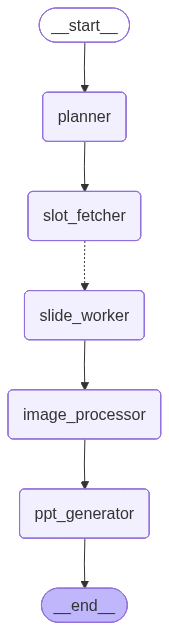

In [156]:
from IPython.display import Image,display
graph_image=app.get_graph().draw_mermaid_png()
display(Image(graph_image))
